In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
aqi=pd.read_csv(r"G:\My Drive\project\maam_ml_project\Air_quality_data.csv")

In [4]:
data=aqi.copy()

In [5]:
data.shape

(18265, 13)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18265 entries, 0 to 18264
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        18265 non-null  object 
 1   Datetime    18265 non-null  object 
 2   PM2.5       18265 non-null  float64
 3   PM10        18265 non-null  float64
 4   NO          18265 non-null  float64
 5   NO2         18265 non-null  float64
 6   NOx         18265 non-null  float64
 7   NH3         18265 non-null  float64
 8   CO          18265 non-null  float64
 9   SO2         18265 non-null  float64
 10  O3          18265 non-null  float64
 11  AQI         18265 non-null  float64
 12  AQI_Bucket  18265 non-null  object 
dtypes: float64(10), object(3)
memory usage: 1.8+ MB


In [7]:
data.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI
count,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000
mean,250.597695,299.442491,100.481035,75.415916,125.964079,25.065042,5.002451,49.835839,100.406740,317.505212
std,144.460292,173.479906,57.774795,43.460066,72.403893,14.452019,2.889439,28.988739,57.591436,113.894816
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,26.900000
25%,125.700000,150.100000,50.600000,37.700000,63.100000,12.600000,2.490000,24.400000,50.600000,207.100000
50%,251.000000,300.300000,100.200000,76.000000,126.200000,25.300000,5.000000,49.900000,100.700000,331.600000
75%,376.200000,450.000000,151.000000,113.200000,188.900000,37.600000,7.510000,75.100000,150.400000,414.000000
max,499.900000,600.000000,200.000000,150.000000,250.000000,50.000000,10.000000,100.000000,200.000000,500.000000


### handling missing value

In [8]:
data.isnull().sum()

City          0
Datetime      0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
AQI           0
AQI_Bucket    0
dtype: int64

## duplicates

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data.dtypes

City           object
Datetime       object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
AQI           float64
AQI_Bucket     object
dtype: object

In [11]:
data["Datetime"]=pd.to_datetime(data["Datetime"],errors="coerce")

In [12]:
data.dtypes

City                  object
Datetime      datetime64[ns]
PM2.5                float64
PM10                 float64
NO                   float64
NO2                  float64
NOx                  float64
NH3                  float64
CO                   float64
SO2                  float64
O3                   float64
AQI                  float64
AQI_Bucket            object
dtype: object

In [13]:
data["Datetime"].isnull().sum()


np.int64(0)

 ### extract date feature

In [14]:
data["Day"]=data["Datetime"].dt.day


In [15]:
data["Month"]=data["Datetime"].dt.month
data["year"]=data["Datetime"].dt.year

###  target variable distribution

In [16]:
data["AQI"].nunique()

3848

In [17]:
## target variable distribution

data["AQI"].describe()

count    18265.000000
mean       317.505212
std        113.894816
min         26.900000
25%        207.100000
50%        331.600000
75%        414.000000
max        500.000000
Name: AQI, dtype: float64

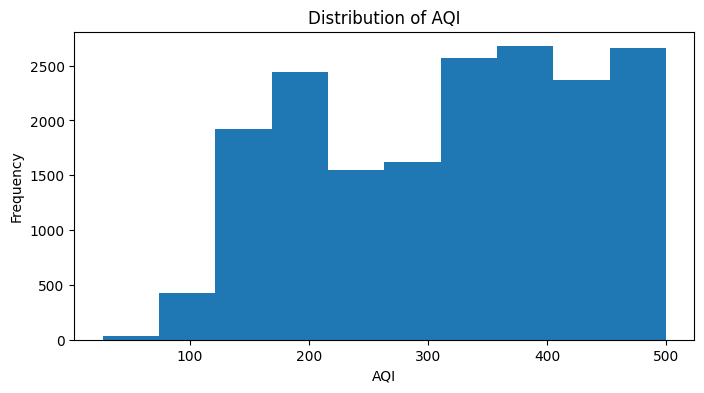

In [18]:
plt.figure(figsize=(8,4))
plt.hist(data["AQI"],bins=10)
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.title("Distribution of AQI")
plt.show()

<Axes: >

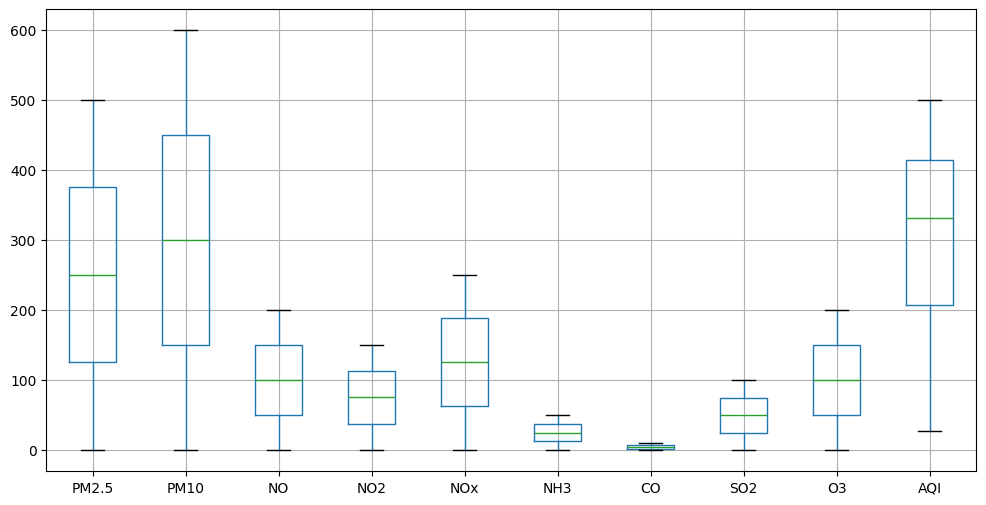

In [19]:
## outlier analysis

data[["PM2.5","PM10","NO","NO2","NOx","NH3","CO","SO2","O3","AQI"]].boxplot(figsize=(12,6))

In [20]:
data.head()

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI,AQI_Bucket,Day,Month,year
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,325.8,Very Poor,1,1,2015
1,Mumbai,2015-01-01,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,262.7,Poor,1,1,2015
2,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,341.8,Very Poor,1,1,2015
3,Kolkata,2015-01-01,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,206.3,Poor,1,1,2015
4,Bangalore,2015-01-01,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,339.8,Very Poor,1,1,2015


In [21]:
data["City"].value_counts() 

City
Delhi        3653
Mumbai       3653
Chennai      3653
Kolkata      3653
Bangalore    3653
Name: count, dtype: int64

### AQI Distribution (TARGET VARIABLE BEHAVIOR)

### How are AQI value distributed overall


#### PURPOSE IS TO OVERALL POLLUTION SEVERITY
- This histogram shows the overall distribution of AQI across all cities and time periods. City-level differences are not shown here because the goal is to understand the general behavior of AQI.


- “This histogram represents a univariate analysis of the AQI variable, which is a continuous numerical feature. The distribution is right-skewed, indicating that while moderate AQI values are common, there are frequent high-pollution events with very high AQI levels. The non-normal and multi-modal nature of the distribution suggests that air pollution severity varies significantly across cities and seasons

In [22]:
# plt.figure(figsize=(8,4))
# plt.hist(data=data,x="AQI",bins=30,kde=True)
# plt.xlabel("AQI")
# plt.ylabel("Frequency")
# plt.title("Distribution of AQI")

# plt.show()

Text(0.5, 1.0, 'Distribution Of AQI With Density Curve')

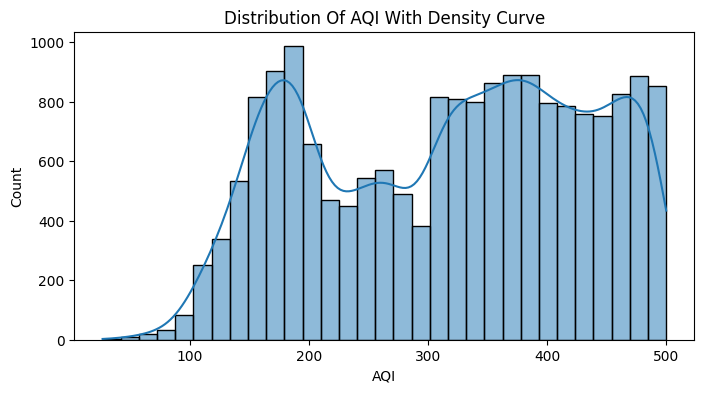

In [23]:
plt.figure(figsize=(8,4))
sns.histplot(data=data,x="AQI",kde=True)
plt.title("Distribution Of AQI With Density Curve")

## AQI by City (THIS IS WHERE CITY COMES)
### PLOT CITY-WISE AVERAGE AQI

- This bar chart shows the average AQI for each city. It highlights that certain cities consistently experience higher pollution levels. Urban and industrial cities tend to have worse air quality, which is important for targeted policy intervention.

- - This boxplot shows the distribution of AQI values across different cities. It highlights variations in median AQI, spread, and extreme pollution events. Some cities consistently experience higher AQI levels, while others show greater variability, indicating frequent pollution spikes.

In [24]:
data["year"].unique()

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
      dtype=int32)

In [25]:
city_api=data.groupby("City")["AQI"].mean().reset_index()
city_api

,City,AQI
0,Bangalore,317.270271
1,Chennai,316.619244
2,Delhi,317.724719
3,Kolkata,317.726992
4,Mumbai,318.184834


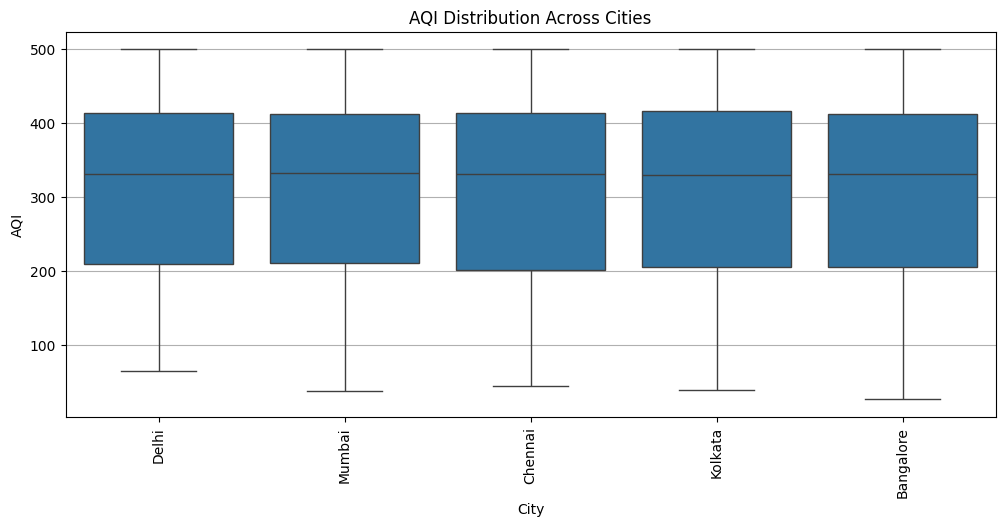

In [26]:
plt.figure(figsize=(12,5))
sns.boxplot(data=data, x="City", y="AQI")
plt.xticks(rotation=90)
plt.title("AQI Distribution Across Cities")
plt.grid(axis="y")
plt.show()

In [27]:
# plt.figure(figsize=(10,5))
# sns.barplot(data=data,x="City",y="AQI")

# # plt.figure(figsize=(10,5))

# plt.xticks(rotation=90)
# plt.title("Average AAQI by City")
# plt.show()

### Which pollutants increase AQI the most?
- These scatter plots show the relationship between AQI and individual pollutant concentrations. A strong upward trend is observed for PM2.5 and PM10, indicating that particulate matter has the highest impact on AQI. Gaseous pollutants such as NO₂ and SO₂ show a moderate relationship, while CO and O₃ have comparatively weaker influence.

- “These scatter plots represent a bivariate analysis between individual pollutants and AQI. A strong positive relationship is observed for PM2.5 and PM10, indicating that particulate matter significantly increases AQI. Gaseous pollutants such as NO₂ and SO₂ show moderate influence, while CO and O₃ exhibit comparatively weaker relationships.”


In [28]:
data.head()

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI,AQI_Bucket,Day,Month,year
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,325.8,Very Poor,1,1,2015
1,Mumbai,2015-01-01,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,262.7,Poor,1,1,2015
2,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,341.8,Very Poor,1,1,2015
3,Kolkata,2015-01-01,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,206.3,Poor,1,1,2015
4,Bangalore,2015-01-01,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,339.8,Very Poor,1,1,2015


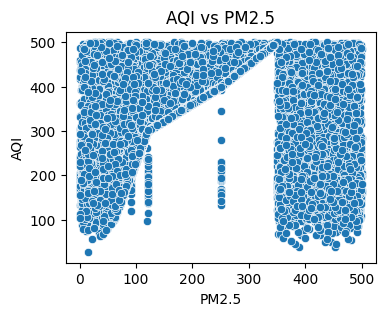

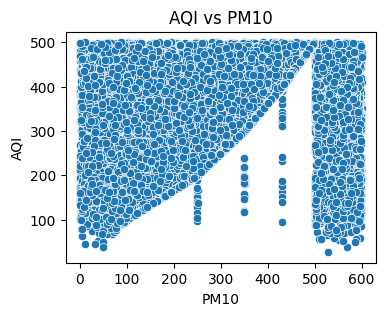

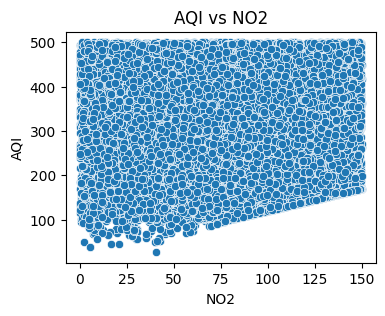

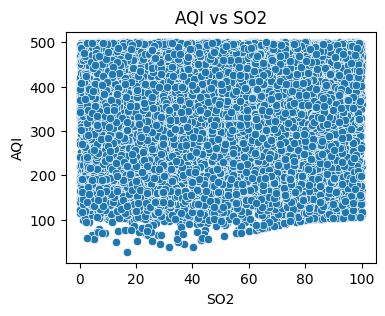

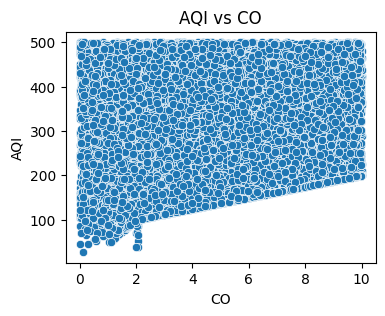

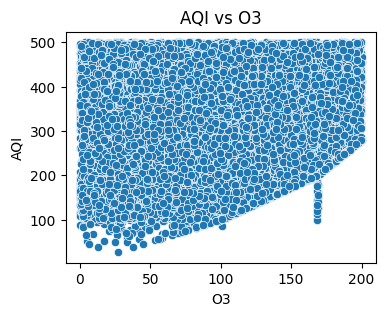

In [29]:
polluatant = ["PM2.5","PM10","NO2","SO2","CO","O3"]

for col in polluatant:
    plt.figure(figsize=(4,3))
    sns.scatterplot(x=data[col], y=data["AQI"])
    plt.xlabel(col)
    plt.ylabel("AQI")
    plt.title(f"AQI vs {col}")
    plt.show()

### Seasonal AQI Trend (TIME-BASED INSIGHT)

- This line plot shows seasonal variation in AQI. Higher AQI values are observed during winter months, likely due to temperature inversion and increased emissions, while lower AQI levels occur during summer and monsoon seasons. This indicates that temporal features are important for AQI prediction.


In [30]:
monthly_aqi=data.groupby("Month")["AQI"].mean()
monthly_aqi

Month
1     318.108258
2     315.026078
3     315.530387
4     319.573533
5     318.920903
6     314.837667
7     320.631548
8     316.796258
9     319.707733
10    319.711742
11    316.222533
12    314.790323
Name: AQI, dtype: float64

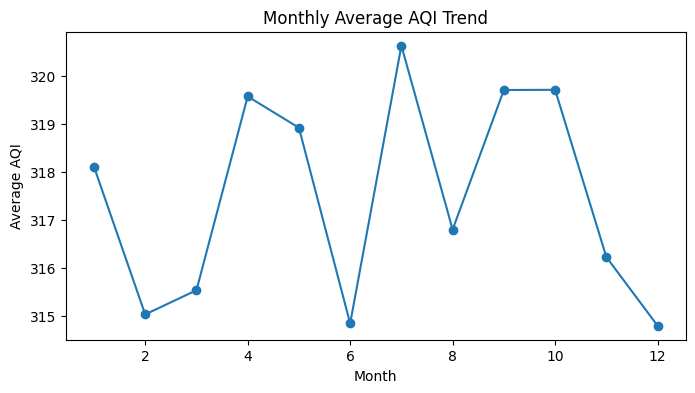

In [31]:
monthly_aqi.plot(kind="line", marker="o", figsize=(8,4))
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.title("Monthly Average AQI Trend")
plt.show()

### AQI Bucket validation 
- This plot validates the AQI categorization by showing a clear increase in AQI values across categories from Good to Severe. This confirms the correctness and consistency of the AQI labels in the dataset.

In [32]:
data["AQI_Bucket"].unique()

array(['Very Poor', 'Poor', 'Severe', 'Moderate', 'Satisfactory', 'Good'],
      dtype=object)

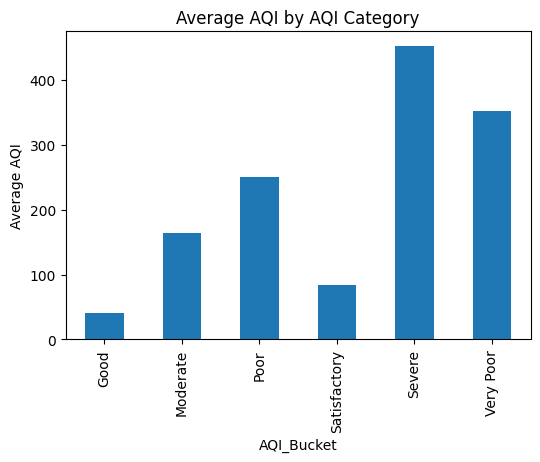

In [33]:
bucket_stats = data.groupby("AQI_Bucket")["AQI"].mean()

bucket_stats.plot(kind="bar", figsize=(6,4))
plt.ylabel("Average AQI")
plt.title("Average AQI by AQI Category")
plt.show()

### Correlation Heatmap of Pollutants and AQI
- Dominant Pollutants Affecting AQI
- 

- “This correlation heatmap shows the linear relationships between different air pollutants and AQI. PM2.5 and PM10 exhibit the strongest positive correlation with AQI, indicating that particulate matter is the primary contributor to air pollution severity. Nitrogen-based pollutants show moderate influence, while other gaseous pollutants have weaker relationships. The heatmap also reveals correlations among pollutants, which is important for feature selection and model design.”

In [34]:
data.head()

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI,AQI_Bucket,Day,Month,year
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,325.8,Very Poor,1,1,2015
1,Mumbai,2015-01-01,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,262.7,Poor,1,1,2015
2,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,341.8,Very Poor,1,1,2015
3,Kolkata,2015-01-01,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,206.3,Poor,1,1,2015
4,Bangalore,2015-01-01,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,339.8,Very Poor,1,1,2015


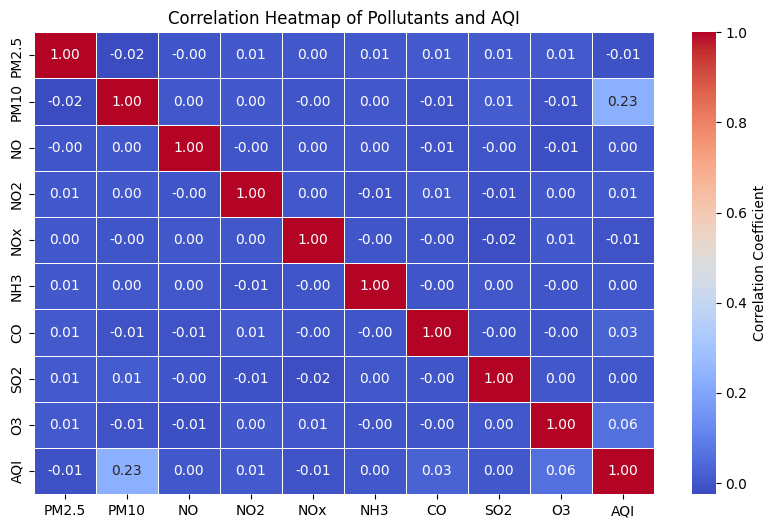

In [35]:
plt.figure(figsize=(10,6))

sns.heatmap(
    data[["PM2.5","PM10","NO","NO2","NOx","NH3","CO","SO2","O3","AQI"]].corr(),
    annot=True,              # show values
    fmt=".2f",               # 2 decimal places
    cmap="coolwarm",
    linewidths=0.5,          # grid lines
    cbar_kws={"label": "Correlation Coefficient"}
)

plt.title("Correlation Heatmap of Pollutants and AQI")
plt.show()
	 

In [36]:
data

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI,AQI_Bucket,Day,Month,year
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,325.8,Very Poor,1,1,2015
1,Mumbai,2015-01-01,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,262.7,Poor,1,1,2015
2,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,341.8,Very Poor,1,1,2015
3,Kolkata,2015-01-01,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,206.3,Poor,1,1,2015
4,Bangalore,2015-01-01,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,339.8,Very Poor,1,1,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18260,Delhi,2024-12-31,371.2,61.7,14.6,130.7,159.1,45.9,7.02,76.4,40.0,162.7,Moderate,31,12,2024
18261,Mumbai,2024-12-31,180.2,259.3,181.9,50.7,135.7,22.4,8.85,12.2,147.3,346.4,Very Poor,31,12,2024
18262,Chennai,2024-12-31,188.6,434.4,68.8,126.1,142.7,47.0,8.30,50.2,128.6,405.9,Severe,31,12,2024
18263,Kolkata,2024-12-31,343.0,458.6,106.7,108.3,137.8,22.6,2.11,71.4,175.8,493.0,Severe,31,12,2024


In [37]:
data.to_csv("air quality",index=False)

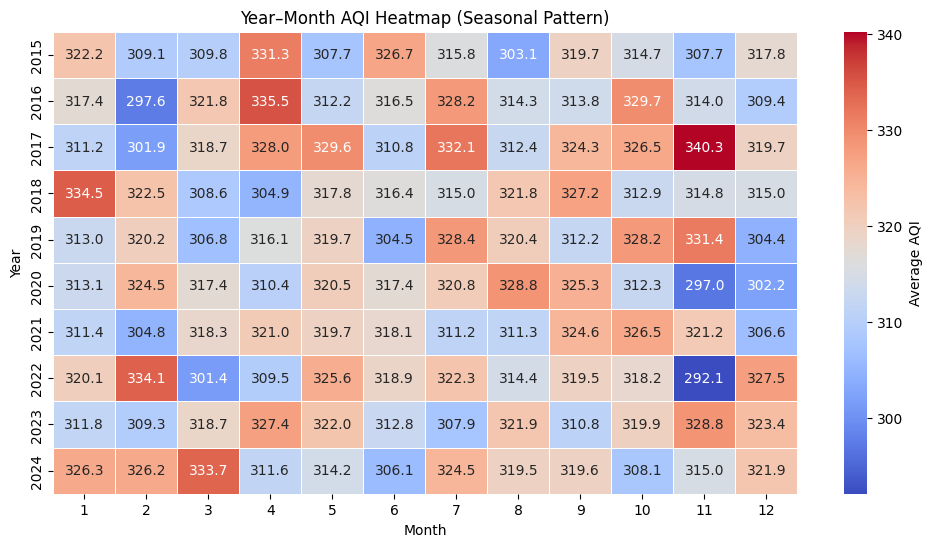

In [39]:
pivot_table = data.pivot_table(
    values="AQI",
    index="year",
    columns="Month",
    aggfunc="mean"
)

plt.figure(figsize=(12,6))


sns.heatmap(
    pivot_table,
    cmap="coolwarm",
    annot=True,        # show values inside cells
    fmt=".1f",         # 1 decimal place
    linewidths=0.5,    # grid lines
    cbar_kws={"label": "Average AQI"}
)

plt.title("Year–Month AQI Heatmap (Seasonal Pattern)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()



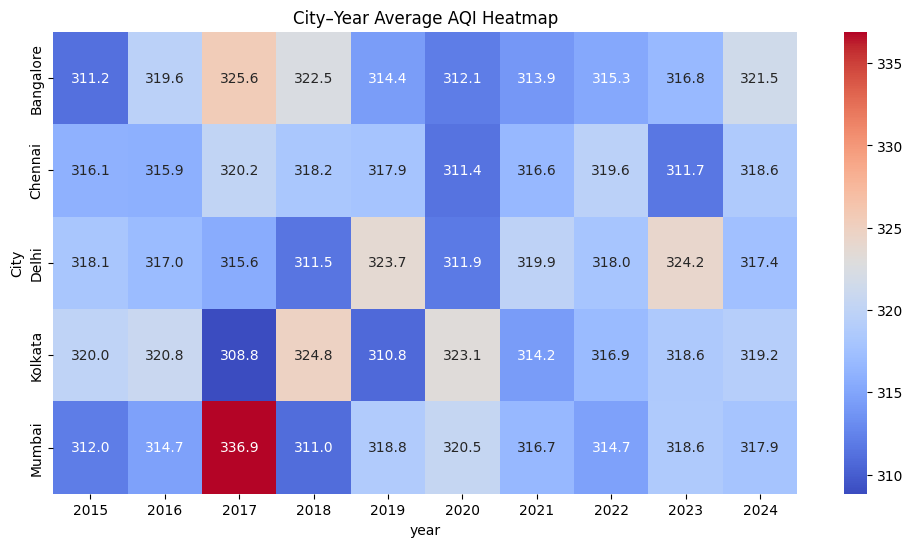

In [41]:
# Create pivot table
city_year_pivot = data.pivot_table(
    values="AQI",
    index="City",
    columns="year",
    aggfunc="mean"
)

# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(
    city_year_pivot,
    cmap="coolwarm",
    annot=True,
    fmt=".1f"
)
plt.title("City–Year Average AQI Heatmap")
plt.xlabel("year")
plt.ylabel("City")
plt.show()
